# **Atividade Prática**
<font size=3>

- **Tema:** Agentes inteligentes.
- **Prazo de entrega:** 01 de Setembro.

---

### **Questão 1:**
<font size=3>
    
Crie um exemplo de **agente reflexo simples** e faça:
 1. A descrição do **PEAS** (_Performance, Ambiente, Atuadores e Sensores_) abaixo, onde está marcado com "_xxx_";
 2. A implementação do **programa do agente** em **Python orientado ao objeto** de acordo com o pseudocódigo abaixo.

<font size=2>
    
>```pseudocode
>function SIMPLE-REFLEX-AGENT(percept) returns an action
>        persistent: rules, a set of condition-action rules
>
>    state ← INTERPRET-INPUT(percept)
>    rule ← RULE-MATCH(state, rules)
>    action ← rule.ACTION
>
>    return action
>```

<font size=3><center>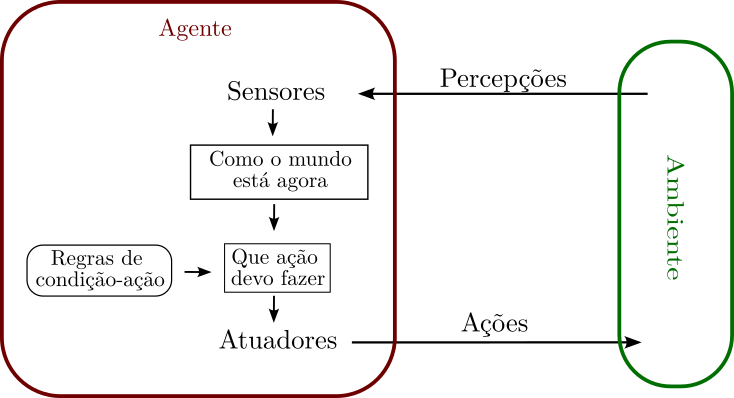</center>

---

### **Resposta:**
<font size=3>

- **Exemplo de agente:** Porta automática com detecção de fumaça
- **PEAS:**

| Categoria       | Descrição                                                                 |
|-----------------|---------------------------------------------------------------------------|
| **Performance** | Abrir e fechar corretamente ao detectar ou não presenças. Abrir ou permanecer aberta ao detectar fumaça. Emitir alerta. |
| **Ambiente**    | Entradas/saídas com fluxo elevado de pessoas.  |
| **Atuadores**   | Motor que controla abertura e fechamento da porta.  |
| **Sensores**    | Sensor de presença, sensor de fumaça endereçável. |

In [3]:
class SimpleReflexAgent:

    def __call__(self, percept):

        state = self.interpret_input(percept)
        action = self.rule_match(state)

        return action

    def interpret_input(self, percept):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")

    def rule_match(self, state):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")
    
class Porta_automatica(SimpleReflexAgent):

    def interpret_input(self, percept):

        presenca, fumaca, status = percept

        return {"presença": presenca, "fumaça": fumaca,"status": status}

    def rule_match(self, state):

        if state["fumaça"] == "Fumaça detectada":
            if state["status"] == "Aberta":
                return "Continuar aberta e disparar um alerta para a central de alarme de incêndio"
            else:
                return "Abrir e disparar um alerta para a central de alarme de incêndio"
        elif state["presença"] == "Presença detectada" and state["fumaça"] != "Fumaça detectada":
            if state["status"] == "Aberta":
                return "Continue aberta"
            else:
                return "Abrir"
        else:
            if state["status"] == "Aberta":
                return "Fechar"
            else:
                return "Continue fechada"

In [5]:
porta = Porta_automatica()

print(porta(["Presença detectada", "Fumaça detectada", "Fechada"]))
print(porta(["Presença detectada", "Fumaça detectada", "Aberta"]))
print()
print(porta(["Nenhuma presença detectada", "Fumaça detectada", "Fechada"]))
print(porta(["Nenhuma presença detectada", "Fumaça detectada", "Aberta"]))
print()
print(porta(["Presença detectada", "Nenhuma fumaça detectada", "Fechada"]))
print(porta(["Presença detectada", "Nenhuma fumaça detectada", "Aberta"]))
print()
print(porta(["Nenhuma presença detectada", "Nenhuma fumaça detectada", "Aberta"]))
print(porta(["Nenhuma presença detectada", "Nenhuma fumaça detectada", "Fechada"]))

Abrir e disparar um alerta para a central de alarme de incêndio
Continuar aberta e disparar um alerta para a central de alarme de incêndio

Abrir e disparar um alerta para a central de alarme de incêndio
Continuar aberta e disparar um alerta para a central de alarme de incêndio

Abrir
Continue aberta

Fechar
Continue fechada


### **Questão 2:**
<font size=3>
    
Crie um exemplo de **agente reflexo baseado em modelo** e faça:
 1. A descrição do **PEAS** (_Performance, Ambiente, Atuadores e Sensores_) abaixo, onde está marcado com "_xxx_";
 2. A implementação do **programa do agente** em **Python orientado ao objeto** de acordo com o pseudocódigo abaixo.

<font size=2>
    
>```pseudocode
>function MODEL-BASED-REFLEX-AGENT(percept) returns an action
>    persistent: state, the agent's current conception of the world state
>                model, a description of how the next state depends on current state and action
>                rules, a set of condition-action rules
>                action, the most recent action, initially none
>
>    state ← UPDATE-STATE(state, action, percept, model)
>    rule ← RULE-MATCH(state, rules)
>    action ← rule.ACTION
>
>    return action
>```

<font size=3><center>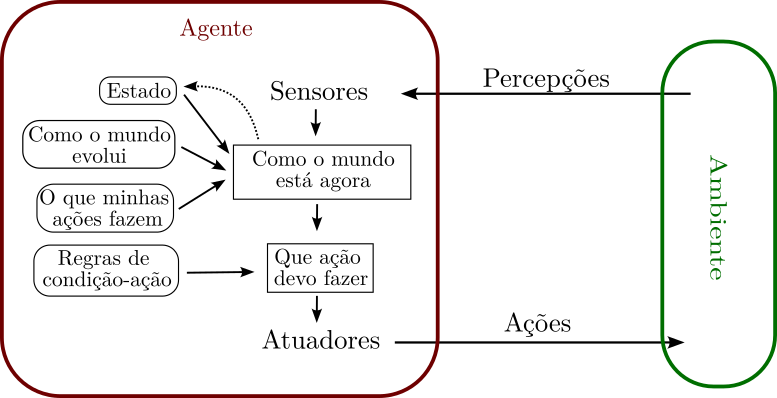</center>

---

### **Resposta:**
<font size=3>

- **Exemplo de agente:** Porta automática com reconhecimento facial
- **PEAS:**

| Categoria       | Descrição                                                                 |
|-----------------|---------------------------------------------------------------------------|
| **Performance** | Detectar presenças e consultar informações cadastradas de quem foi detectado. Abrir corretamente ao constatar pessoas autorizadas. Fechar para pessoas não autorizadas e emitir uma notificação de acesso negado. |
| **Ambiente**    | Entradas/saídas com fluxo controlado de pessoas.  |
| **Atuadores**   | Motor que controla abertura e fechamento da porta. Autofalante |
| **Sensores**    | Sensor de presença, câmera com reconhecimento facial. |

In [ ]:
class ModelBasedReflexAgent:

    def __init__(self):
        self.state : dict = None
        self.action : str = None
        self.model : dict = None
        self.rules : set = None

    def __call__(self, percept):
        self.state = self.update_state(self.state, self.action, percept, self.model)
        rule = self.rule_match(self.state, self.rules)

        return rule.action

    def rule_match(self, state, rules):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")

    def update_state(state, action, percept, model):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")
    
class Porta_acesso_facial(ModelBasedReflexAgent):

    def __init__(self):
        self.state : dict = {
            "Status": "Fechado", 
            "Quantidade de pessoas atualmente no ambiente": 0, 
            "Tentativa de acesso": None, 
            "Pessoas que acessaram o ambiente": set()
            }
        self.action : str = None
        self.model : dict = None
        self.rules : set = None
    def update_state(state, action, percept, model):
        presenca = percept
        return {"presença": presenca}
    
    def rule_match(self, state, rules):
        pass